In [2]:
data_dir = "/home/mjehangir/telomere-sv-analysis/data/aysa_SVs/"
#data_dir = "/scratch/mjehangir/aysa_severus_results/"
setwd(data_dir)


In [6]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(scales)
library(forcats)

In [7]:
# --- 1. DATA LOADING & PREPARATION ---
outdir <- "/home/mjehangir/telomere-sv-analysis/plots/fig2/severus/"
dir.create(outdir, showWarnings = FALSE, recursive = TRUE)

In [8]:
data <- read.table("./severus_reshaped.tsv", header = TRUE, sep = "\t")

In [9]:
# Standardize and Filter
data <- data %>%
  dplyr::rename(filename = sample) %>%
  filter(chr %in% paste0("chr", 1:22)) %>%
  mutate(type = factor(type, levels = c("DEL", "DUP", "INS", "INV", "BND")))

In [10]:
# Define Universal SV Colors
sv_colors <- c(
  "DEL" = "skyblue3",
  "DUP" = "orangered",
  "INS" = "green4",
  "INV" = "orange",
  "BND" = "pink"
)

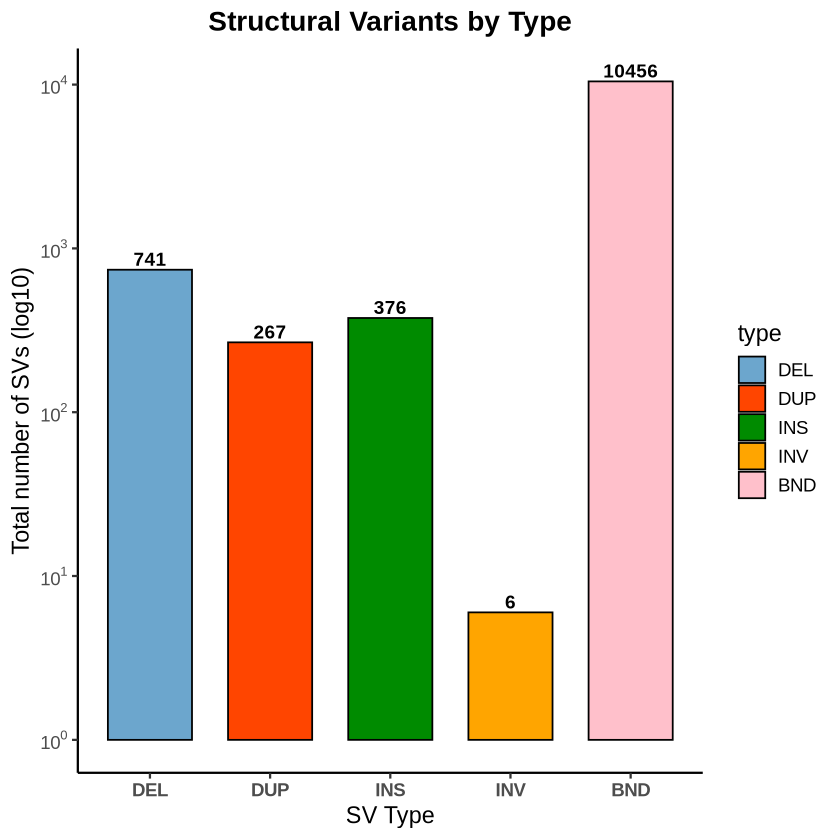

In [11]:
# --- 2. GLOBAL SV STATISTICS BY TYPE ---
sv_summary <- data %>% count(type)

p_type_log <- ggplot(sv_summary, aes(x = type, y = n, fill = type)) +
  geom_bar(stat = "identity", color = "black", width = 0.7) +
  scale_fill_manual(values = sv_colors) +
  scale_y_log10(breaks = trans_breaks("log10", function(x) 10^x),
                labels = trans_format("log10", math_format(10^.x))) +
  geom_text(aes(label = n), vjust = -0.3, size = 4, fontface = "bold") +
  labs(x = "SV Type", y = "Total number of SVs (log10)", title = "Structural Variants by Type") +
  theme_classic(base_size = 14) +
  theme(axis.text.x = element_text(face = "bold"),
        plot.title = element_text(face = "bold", hjust = 0.5))
                        p_type_log


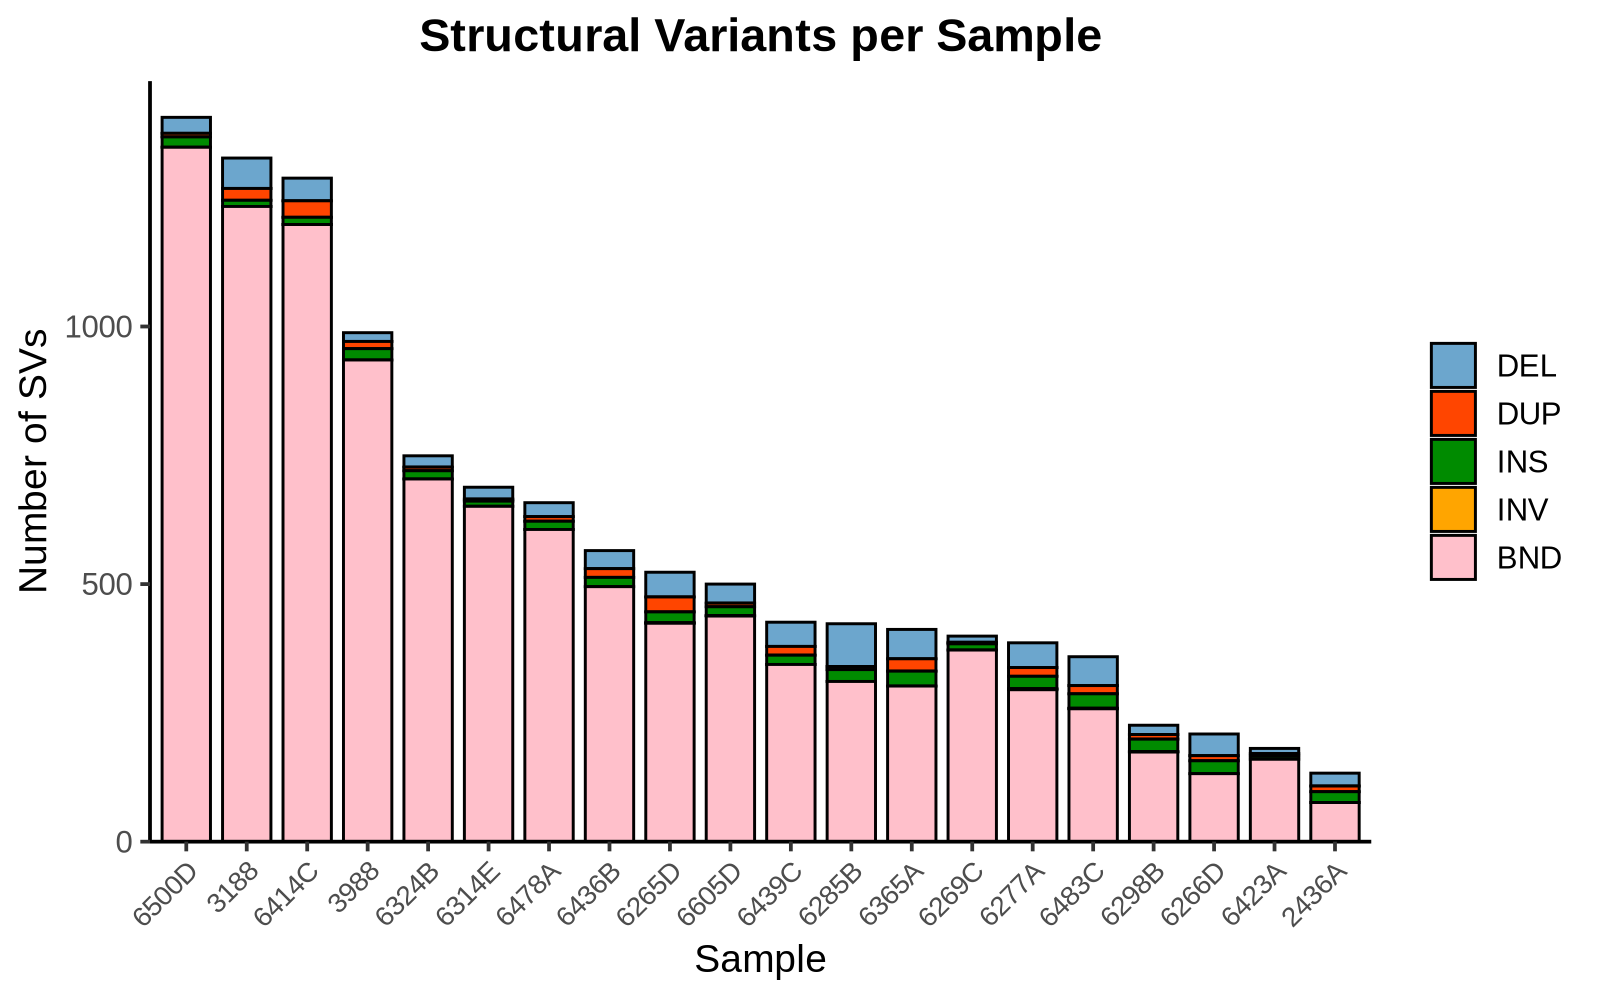

In [13]:
#ggsave(file.path(outdir, "supply_SV_by_type_log.pdf"), plot = p_type_log, width = 6, height = 5)

# --- 3. SV BURDEN PER SAMPLE (STACKED & SORTED) ---
sample_order <- data %>%
  count(filename) %>%
  arrange(desc(n)) %>%
  pull(filename)

p_burden <- data %>%
  count(filename, type) %>%
  mutate(filename = factor(filename, levels = sample_order)) %>%
  ggplot(aes(x = filename, y = n, fill = type)) +
  geom_bar(stat = "identity", position = "stack", color = "black", width = 0.8) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +
  scale_fill_manual(values = sv_colors) +
  labs(x = "Sample", y = "Number of SVs", title = "Structural Variants per Sample") +
  theme_classic(base_size = 14) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 10),
        plot.title = element_text(face = "bold", hjust = 0.5),
        legend.title = element_blank())

#ggsave(file.path(outdir, "total_SV_count_v2.pdf"), plot = p_burden, width = 8, height = 5)
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 200)

p_burden

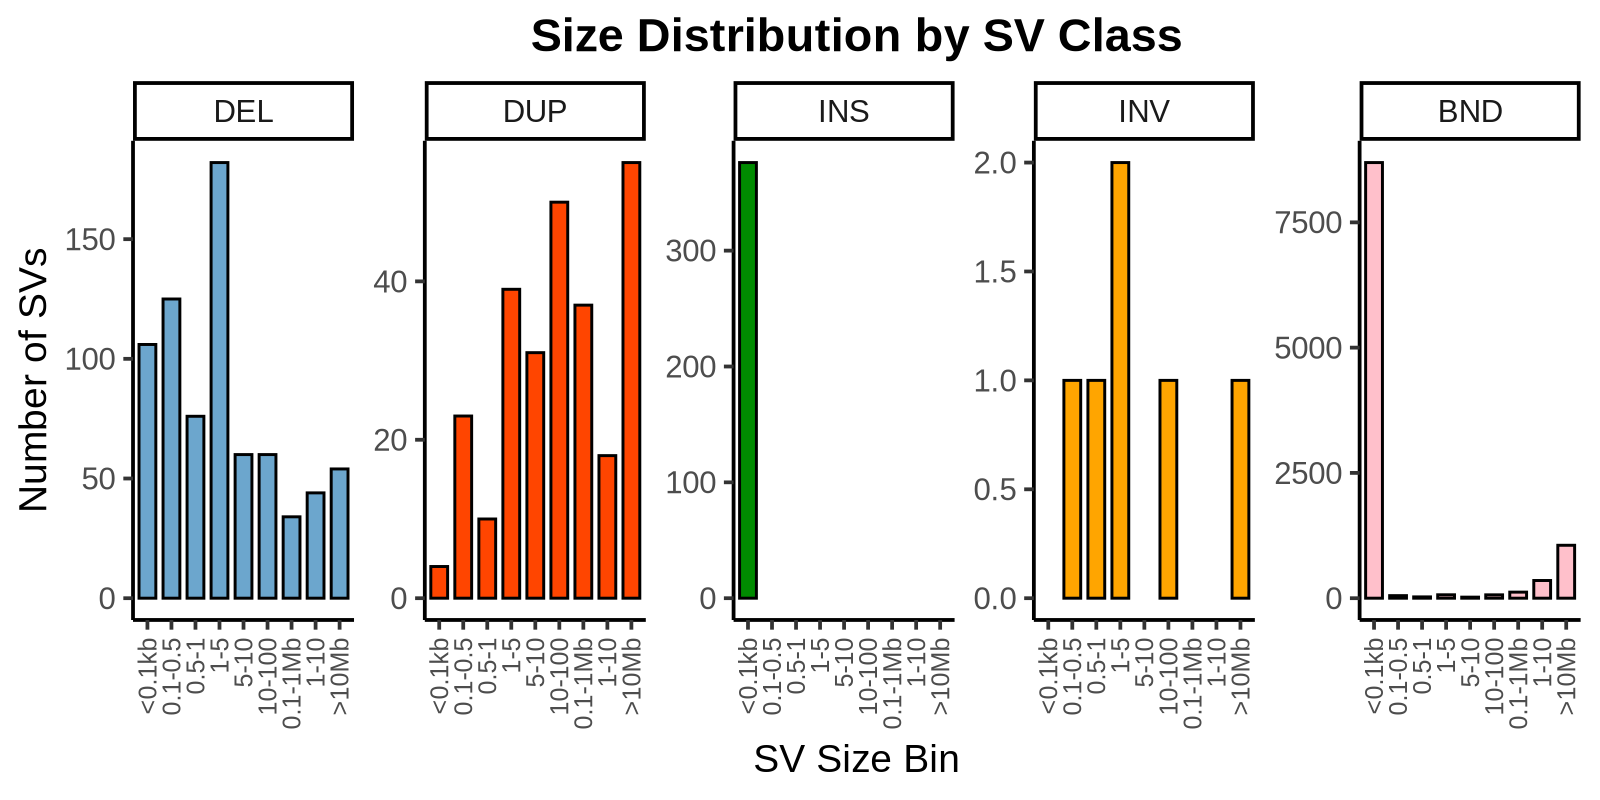

In [15]:
# --- 4. SIZE DISTRIBUTION BY TYPE ---
data_bins <- data %>%
  mutate(size_bin = cut(size,
      breaks = c(0, 1e2, 5e2, 1e3, 5e3, 1e4, 1e5, 1e6, 1e7, Inf),
      labels = c("<0.1kb", "0.1-0.5", "0.5-1", "1-5", "5-10", "10-100", "0.1-1Mb", "1-10", ">10Mb"),
      right = FALSE, include.lowest = TRUE))

p_size <- data_bins %>%
  count(size_bin, type) %>%
  ggplot(aes(x = size_bin, y = n, fill = type)) +
  geom_bar(stat = "identity", color = "black", width = 0.7) +
  scale_fill_manual(values = sv_colors) +
  facet_wrap(~ type, scales = "free_y", nrow = 1) +
  labs(x = "SV Size Bin", y = "Number of SVs", title = "Size Distribution by SV Class") +
  theme_classic(base_size = 14) +
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 9),
        plot.title = element_text(face = "bold", hjust = 0.5),
        legend.position = "none")

#ggsave(file.path(outdir, "size_distribution_v2.pdf"), plot = p_size, width = 14, height = 5)
options(repr.plot.width = 8, repr.plot.height = 4, repr.plot.res = 200)

p_size

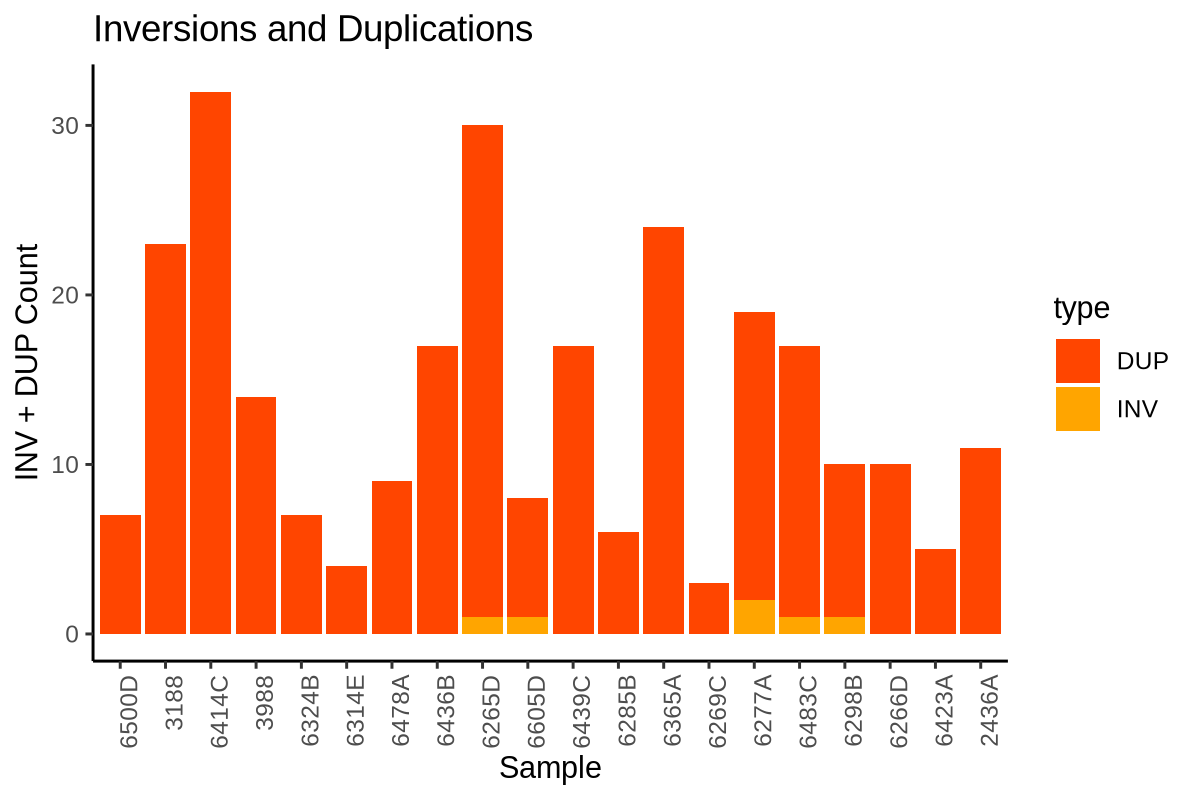

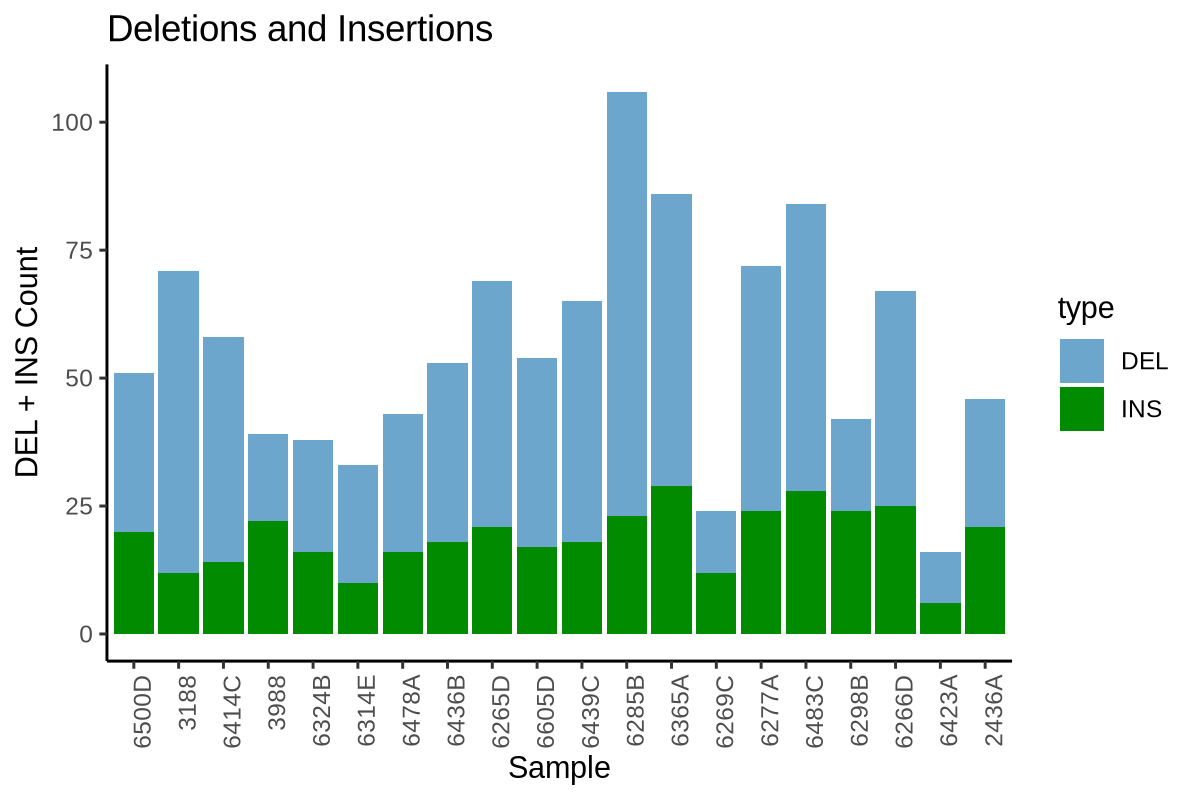

In [18]:
# --- 5. SUBSET BURDEN PLOTS (INV/DUP & DEL/INS) ---
# Combined INV + DUP
p_inv_dup <- data %>%
  filter(type %in% c("INV", "DUP")) %>%
  mutate(filename = factor(filename, levels = sample_order)) %>%
  ggplot(aes(x = filename, fill = type)) +
  geom_bar(position = "stack") +
  scale_fill_manual(values = sv_colors) +
  labs(x = "Sample", y = "INV + DUP Count", title = "Inversions and Duplications") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))

# Combined DEL + INS
p_del_ins <- data %>%
  filter(type %in% c("DEL", "INS")) %>%
  mutate(filename = factor(filename, levels = sample_order)) %>%
  ggplot(aes(x = filename, fill = type)) +
  geom_bar(position = "stack") +
  scale_fill_manual(values = sv_colors) +
  labs(x = "Sample", y = "DEL + INS Count", title = "Deletions and Insertions") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))
options(repr.plot.width = 6, repr.plot.height = 4, repr.plot.res = 200)

p_inv_dup
p_del_ins